"""
Hi ;)
Feel free to either skim or try out the notebook yourselves, as the very reason that prompted me to create such a thing lies in sharing the set of practices I usually draw upon when doing EDA (exploratory data analysis), IDA (in-depth data analysis), and naive model selection. The whole process was already encapsulated in a Python script/function you can make use of. Please check the auto_Model_Selection.py file.

Please, do not hold back from providing notes for improvement or any sort of constructive feedback.

The document is structured as follows:

** Libraries;

** Utilities;

** Data Analysis;

** Model Selection;
"""


# **Libraries**
Please run for smoothless execution :p

In [27]:
### Common python imports - Starts
import pandas as pd
from matplotlib import pyplot as PLT
import numpy
### Common python imports - Ends

### M.L. specific imports - Starts
from argparse import ArgumentParser
import pycaret 
from pycaret.time_series import TSForecastingExperiment
### M.L. specific improts - Ends

# **Utilities**
Needs to be included in any run as well.

In [4]:

def argparser():
    args = ArgumentParser("General variables to be defined beforehand of the execution")
    args.add_argument("--go-p", type=str,default=r"D:\Cristi_s_ground\University\HTT\Project\HTTStockIndustryRankingTool\Gold and Silver\Data\Gold\Demand and Supply\GDT Tables_Q424_EN.xlsx", help="Path to gold overview")

    args, unknown = args.parse_known_args()
    return args 

args = argparser()

# **Data Analysis**

## 1. **Exploratory Data Analysis**

### Gold Demand vs Supply 
In order to be able to determine whether a certain business establishment (whose activity mainly revolves around the jewelry industry) is actually doing a decent job in capitalizing on gold swings, we must be able to identify in advance when such a decrease or increase in either of the two—demand or supply—becomes prevalent. Only then can we tell with a somewhat increased degree of confidence that the firm X was, say, capable of expanding their gold holdings at the right moment. Nevertheless, a model that is able to predict these "swings" or seasonal trends will be of imperative need.

In [5]:
data = pd.read_excel(args.go_p,sheet_name='Gold Balance',engine='openpyxl')
data[:10]

,▲,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81
0,▼,Tonnes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Gold supply and demand WGC presentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,2010.000000,2011.000000,2012.000000,2013.000000,2014.000000,2015.000000,2016.000000,2017.000000,...,Q1'23,Q2'23,Q3'23,Q4'23,Q1'24,Q2'24,Q3'24,Q4'24,NaN,Year-on-year % change
4,NaN,Supply,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Mine production,2754.465101,2876.861923,2957.201294,3167.336197,3271.731155,3362.373888,3516.241324,3580.564245,...,854.07859,899.198472,935.432619,955.364951,865.020237,899.323998,943.270604,953.618327,▼,-0.182823
6,NaN,Net producer hedging,-108.808409,22.525497,-45.315364,-27.939442,104.907298,12.891945,37.634305,-25.520056,...,39.216924,-15.544419,23.835591,19.865976,-8.278008,-19.566459,-13.906231,-15.014763,▲,-
7,NaN,Recycled gold,1671.163847,1626.331320,1636.762755,1195.308331,1129.588570,1067.074981,1232.142588,1112.392781,...,309.523636,324.020015,289.65241,311.234134,349.377746,336.472593,325.351359,358.799863,▲,15.282941
8,NaN,Total supply,4316.820540,4525.718740,4548.648686,4334.705085,4506.227023,4442.340814,4786.018218,4667.436970,...,1202.81915,1207.674068,1248.920621,1286.465061,1206.119974,1216.230132,1254.715732,1297.403428,▲,0.850265
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Supply - Can we predict quarterly the supply of gold?


In [6]:
# 1. Scrapping data to create variable of interest: Mine Production, Price, Mine production, Net producer hedging, Recycled gold
mine_production = pd.DataFrame({'Supply':data.iloc[5], 'Quarter period':data.iloc[3]}).dropna()
net_producer = pd.DataFrame({'Net Production':data.iloc[6], 'Quarter period':data.iloc[3]}).dropna()
recycled_gold = pd.DataFrame({'Recycled Gold':data.iloc[7], "Quarter period":data.iloc[3]}).dropna()
total_supply = pd.DataFrame({'Total Supply':data.iloc[8], "Quarter period":data.iloc[3]})

general_mine_production, general_net_producer, general_recycled_gold, general_gold_supply = mine_production[:15].dropna(), net_producer[:15].dropna(), recycled_gold[:15].dropna(), total_supply[:15].dropna()

# 2. Creating time index (Quarter to Month)
general_mine_production.index = general_mine_production['Quarter period'].astype(int).drop(columns='Quarter period')
general_net_producer.index = general_net_producer['Quarter period'].astype(int).drop(columns='Quarter period')
general_recycled_gold.index = general_recycled_gold['Quarter period'].astype(int).drop(columns='Quarter period')

# !!! Mine Production
mine_production = mine_production[16:].copy() 
extract = mine_production['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
mine_production['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
mine_production['Date'] = pd.to_datetime(mine_production['Date_Clean'])
# Convert your target data to numeric
mine_production['Supply'] = pd.to_numeric(mine_production['Supply'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_mine_production = (mine_production[['Date', 'Supply']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))

# !!! Net producer
net_producer = net_producer[16:].copy()
extract = net_producer['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
net_producer['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
net_producer['Date'] = pd.to_datetime(net_producer['Date_Clean'])
# Convert your target data to numeric
net_producer['Net Production'] = pd.to_numeric(net_producer['Net Production'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_net_producer = (net_producer[['Date', 'Net Production']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))


# !!! Recycled gold
recycled_gold = recycled_gold[16:]
extract = recycled_gold['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
recycled_gold['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
recycled_gold['Date'] = pd.to_datetime(recycled_gold['Date_Clean'])
# Convert your target data to numeric
recycled_gold['Recycled Gold'] = pd.to_numeric(recycled_gold['Recycled Gold'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_recycled_gold = (recycled_gold[['Date', 'Recycled Gold']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))

# !!! Total supply
total_supply = total_supply[16:].copy()
extract = total_supply['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
total_supply['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
total_supply['Date'] = pd.to_datetime(total_supply['Date_Clean'])
# Convert your target data to numeric
total_supply['Total Supply'] = pd.to_numeric(total_supply['Total Supply'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_total_supply = (total_supply[['Date', 'Total Supply']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))


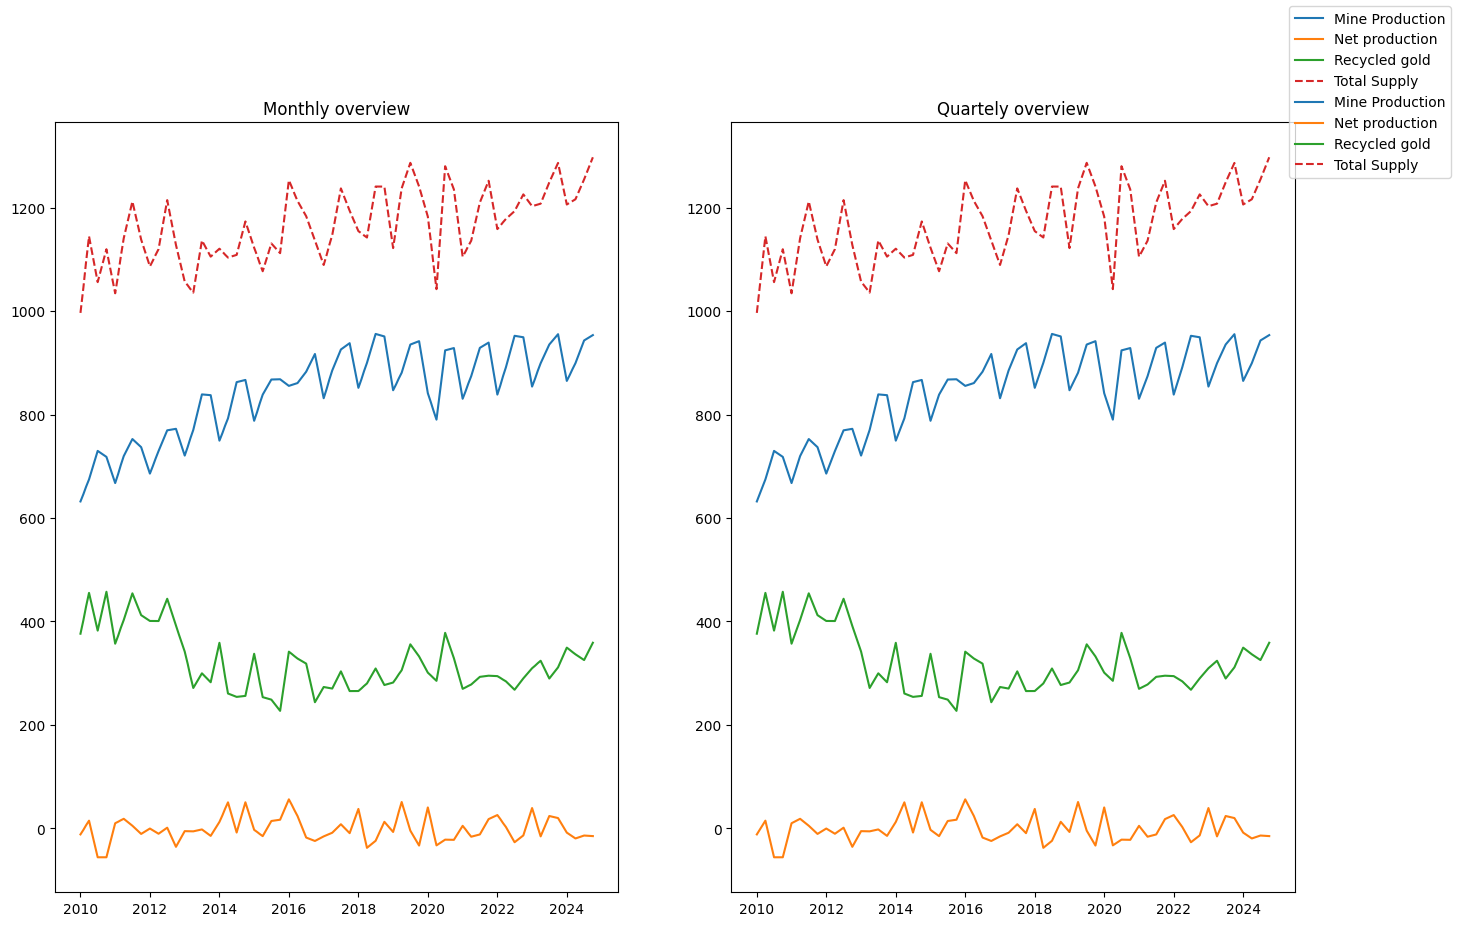

In [ ]:
fig, axis = PLT.subplots(1, 2, figsize = (16,10))
axis[0].set_title("Monthly overview")
axis[0].plot(df_monthly_mine_production, label = "Mine Production")
axis[0].plot(df_monthly_net_producer, label = "Net production")
axis[0].plot(df_monthly_recycled_gold, label = "Recycled gold")
axis[0].plot(df_monthly_total_supply, label="Total Supply", linestyle='dashed')

axis[1].set_title("Quartely overview")
axis[1].plot(mine_production['Date'], mine_production['Supply'], label= "Mine Production")
axis[1].plot(net_producer['Date'], net_producer['Net Production'], label= "Net production")
axis[1].plot(recycled_gold['Date'], recycled_gold['Recycled Gold'], label= "Recycled gold")
axis[1].plot(total_supply['Date'], total_supply['Total Supply'], label="Total Supply", linestyle='dashed')

fig.legend()

# 1.**Model selection**

## 1.1. Naive model selection

### 1.1.1 Gold supply - Monthly

In [28]:
# Init the TSForecaster object which allows us use 'setup', 'model_selection' and other py-caret time-series modules;
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_total_supply, target='Total Supply',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

,Description,Value
0,session_id,134
1,Target,Total Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(178, 1)"
5,Transformed data shape,"(178, 1)"
6,Transformed train set shape,"(166, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.7636,0.7847,38.8416,48.1230,0.0328,0.0325,-0.5655,0.3260
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.7645,0.7912,38.8703,48.5075,0.0329,0.0325,-0.5475,0.2080
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.7630,0.7851,38.8055,48.1474,0.0328,0.0325,-0.5662,0.2620
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.7648,0.7828,38.9137,48.0204,0.0329,0.0326,-0.5935,1.3580
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.7648,0.7828,38.9136,48.0219,0.0329,0.0326,-0.5932,0.2000
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.7655,0.7867,38.9338,48.2477,0.0329,0.0326,-0.5627,0.2480
polytrend,Polynomial Trend Forecaster,0.8158,0.8346,41.5665,51.2549,0.0354,0.0348,-0.5270,0.0500
croston,Croston,0.8366,0.8493,42.6519,52.1794,0.0361,0.0357,-0.5385,0.0300
auto_arima,Auto ARIMA,0.8716,0.8530,44.3907,52.3399,0.0376,0.0372,-0.5340,15.8420
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.8840,0.9024,45.1888,55.4278,0.0388,0.0377,-1.0327,0.2860


In [29]:
# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ElasticNet,0.5316,0.4881,28.0809,30.7880,0.0225,0.0226,-0.1299


### 1.1.2. Gold supply - Quarter

In [43]:
total_supply_for_pred = total_supply.drop(columns=['Quarter period', 'Date_Clean']).dropna() # Clearing out the raw data set from NaN(s)
total_supply_for_pred.index = total_supply_for_pred['Date']
total_supply_for_pred = total_supply_for_pred.drop(columns=['Date'])
model = None # PyCarret zero_gradient() seems troublesome thus erasing the gradient memory manually
model = TSForecastingExperiment()

#### One quarter

In [44]:
model.setup(total_supply_for_pred, target='Total Supply', fh=1, session_id = 135) # fh = 1 ~ means one quarter
_best_gold_quarter = model.compare_models(n_select=10, sort='SMAPE')

model.predict_model(_best_gold_quarter[0])

model.plot_model(_best_gold_quarter[0])

,Description,Value
0,session_id,135
1,Target,Total Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(59, 1)"
7,Transformed test set shape,"(1, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,TT (Sec)
auto_arima,Auto ARIMA,0.1936,0.1577,11.9618,11.9618,0.0099,0.0098,1.5200
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.3125,0.2546,19.2845,19.2845,0.0158,0.0157,0.1400
croston,Croston,0.3145,0.2560,19.3109,19.3109,0.0155,0.0157,0.0267
theta,Theta Forecaster,0.3227,0.2628,19.8720,19.8720,0.0161,0.0162,0.0400
polytrend,Polynomial Trend Forecaster,0.3411,0.2779,21.0495,21.0495,0.0172,0.0171,0.0367
exp_smooth,Exponential Smoothing,0.3411,0.2779,21.0495,21.0495,0.0172,0.0171,0.0433
ets,ETS,0.3411,0.2779,21.0495,21.0495,0.0172,0.0171,0.0667
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.3504,0.2856,21.6331,21.6331,0.0177,0.0176,0.0567
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.3678,0.2997,22.7030,22.7030,0.0186,0.0185,0.1000
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.3678,0.2997,22.7059,22.7059,0.0186,0.0185,0.0500


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE
0,Auto ARIMA,0.4286,0.3484,26.0775,26.0775,0.0201,0.0203


#### Half year

In [51]:
model.setup(total_supply_for_pred, target='Total Supply', fh=2, session_id = 135) # fh = 2 ~ Halfyear
_best_gold_quarter = model.compare_models(n_select=10, sort='SMAPE')
model.predict_model(_best_gold_quarter[0])
model.plot_model(_best_gold_quarter[0])

,Description,Value
0,session_id,135
1,Target,Total Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(58, 1)"
7,Transformed test set shape,"(2, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
exp_smooth,Exponential Smoothing,0.3527,0.3093,22.1388,23.7835,0.0179,0.0179,-18.0825,0.0400
theta,Theta Forecaster,0.4287,0.3659,26.8091,28.0935,0.0213,0.0217,-7.2458,0.0700
polytrend,Polynomial Trend Forecaster,0.4350,0.3708,27.2996,28.5150,0.0219,0.0221,-19.2039,0.0200
ets,ETS,0.4350,0.3708,27.2992,28.5146,0.0219,0.0221,-19.2028,0.0533
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.4443,0.3789,27.8919,29.1403,0.0225,0.0226,-23.2674,0.0733
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.4585,0.3911,28.7741,30.0684,0.0232,0.0233,-25.4604,0.1600
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.4584,0.3911,28.7715,30.0657,0.0232,0.0233,-25.4539,0.0633
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.4585,0.3911,28.7741,30.0684,0.0232,0.0233,-25.4604,0.0900
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.4585,0.3911,28.7741,30.0684,0.0232,0.0233,-25.4604,0.0867
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.4584,0.3910,28.7692,30.0633,0.0232,0.0233,-25.4480,0.0633


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Exponential Smoothing,0.6633,0.6018,40.6218,45.3270,0.0316,0.0322,-3.5099


#### One year

In [ ]:
model.setup(total_supply_for_pred, target='Total Supply', fh=3, session_id = 135) # fh = 3 ~ One Year
_best_gold_quarter = model.compare_models(n_select=10, sort='SMAPE')
model.predict_model(_best_gold_quarter[0])
model.plot_model(_best_gold_quarter[0])

,Description,Value
0,session_id,135
1,Target,Total Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(57, 1)"
7,Transformed test set shape,"(3, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
theta,Theta Forecaster,0.4318,0.4285,27.7968,33.5471,0.0226,0.0229,-2.4687,0.0300
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.4710,0.5009,30.1716,39.1155,0.0244,0.0249,-3.1260,0.1500
polytrend,Polynomial Trend Forecaster,0.4721,0.4157,30.5948,32.7009,0.0252,0.0251,-3.2854,0.0300
ets,ETS,0.4724,0.4159,30.6153,32.7203,0.0253,0.0252,-3.2939,0.0567
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.4819,0.4230,31.2594,33.2963,0.0258,0.0257,-3.6221,0.0667
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.4896,0.4293,31.7632,33.8023,0.0262,0.0261,-3.8231,0.0733
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.4896,0.4293,31.7619,33.8011,0.0262,0.0261,-3.8226,0.0633
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.4896,0.4293,31.7646,33.8037,0.0262,0.0261,-3.8237,0.1067
exp_smooth,Exponential Smoothing,0.4901,0.4372,31.8327,34.4601,0.0264,0.0261,-4.5955,0.0300
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.4896,0.4293,31.7646,33.8037,0.0262,0.0261,-3.8237,0.0900


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Theta Forecaster,0.5743,0.5769,35.6958,43.8337,0.0279,0.0285,-0.7480


### Mine Production

In [23]:
# ...zero_grad() lacks thus the cache memory of the gradiens must be erased 'by hand'
model = None
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_mine_production, target='Supply',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Description,Value
0,session_id,134
1,Target,Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(178, 1)"
5,Transformed data shape,"(178, 1)"
6,Transformed train set shape,"(166, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
snaive,Seasonal Naive Forecaster,0.6791,0.7312,18.6232,23.3287,0.0213,0.0212,0.5746,0.0340
arima,ARIMA,0.7620,0.8439,21.1040,26.9576,0.0240,0.0237,0.3532,0.0660
theta,Theta Forecaster,0.7732,0.7764,21.3548,24.6917,0.0245,0.0239,0.4600,0.0240
exp_smooth,Exponential Smoothing,0.8634,0.8288,23.7163,26.3349,0.0271,0.0264,0.4283,0.0600
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.9341,0.9253,25.7937,29.4914,0.0292,0.0284,0.2409,0.1900
stlf,STLF,0.9401,0.9488,25.9931,30.3451,0.0294,0.0291,0.2584,0.0280
ets,ETS,0.9591,0.9203,26.4671,29.2722,0.0301,0.0293,0.2439,0.1580
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,1.0282,0.9823,28.3910,31.2792,0.0323,0.0313,0.0615,0.4080
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,1.0297,0.9834,28.4311,31.3135,0.0323,0.0313,0.0595,0.1500
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.0349,0.9924,28.5434,31.5205,0.0327,0.0315,0.0637,0.3120


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Seasonal Naive Forecaster,0.2091,0.2025,5.2206,6.1535,0.0058,0.0058,0.9554


### Net Production

In [24]:
# ...zero_grad() lacks thus the cache memory of the gradiens must be erased 'by hand'
model = None
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_net_producer, target='Net Production',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Description,Value
0,session_id,134
1,Target,Net Production
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(178, 1)"
5,Transformed data shape,"(178, 1)"
6,Transformed train set shape,"(166, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.1812,1.1077,18.6035,22.9362,2.1003,1.2570,-1.2196,0.2180
theta,Theta Forecaster,1.3950,1.2923,21.9240,26.7112,2.4745,1.2679,-1.8081,0.0540
naive,Naive Forecaster,1.4007,1.2936,22.0165,26.7404,2.4742,1.2724,-1.8255,0.0360
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,1.4400,1.3003,22.6242,26.8690,2.7821,1.2827,-1.4471,0.2920
stlf,STLF,1.4550,1.3304,22.8758,27.5059,2.5981,1.2850,-1.9942,0.0400
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,1.9645,1.6204,30.9062,33.3876,3.5947,1.3011,-3.5162,0.2440
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,1.3390,1.2712,21.0052,26.2616,2.0306,1.3015,-1.7692,0.3080
snaive,Seasonal Naive Forecaster,1.3490,1.2576,21.1984,25.9881,2.3970,1.3294,-1.8018,0.0440
arima,ARIMA,1.8159,1.6198,28.5256,33.4368,3.4484,1.3340,-2.7243,0.0500
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.4237,1.2752,22.3416,26.3080,3.1341,1.3642,-1.4405,0.1520


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,LGBMRegressor,0.7396,0.6589,11.7494,13.7008,1.9145,1.1156,-1.7197


### Recycled gold

In [25]:
# ...zero_grad() lacks thus the cache memory of the gradiens must be erased 'by hand'
model = None
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_recycled_gold, target='Recycled Gold',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Description,Value
0,session_id,134
1,Target,Recycled Gold
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(178, 1)"
5,Transformed data shape,"(178, 1)"
6,Transformed train set shape,"(166, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.6600,0.5815,22.3844,27.5290,0.0717,0.0728,-2.4242,0.4240
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.7171,0.6047,24.2163,28.5834,0.0799,0.0784,-3.5365,0.3400
snaive,Seasonal Naive Forecaster,0.7199,0.5906,24.0588,27.6240,0.0790,0.0791,-4.4712,0.0380
auto_arima,Auto ARIMA,0.7205,0.5913,24.2290,27.8143,0.0796,0.0792,-3.7021,10.7120
croston,Croston,0.7617,0.6329,25.5478,29.7580,0.0830,0.0833,-4.0171,0.0160
naive,Naive Forecaster,0.7894,0.6464,26.5575,30.4772,0.0869,0.0865,-4.2648,0.0560
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,0.7805,0.6579,26.5168,31.2576,0.0842,0.0878,-2.7654,0.3440
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.7985,0.6691,27.0275,31.6971,0.0853,0.0909,-3.4054,0.2360
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.7984,0.6690,27.0257,31.6949,0.0853,0.0909,-3.4048,0.1640
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.8024,0.6725,27.1578,31.8572,0.0857,0.0914,-3.4638,0.2440


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,RandomForestRegressor,0.6180,0.5454,19.0249,23.3715,0.0554,0.0578,-4.5517


In [ ]:

#TODO - Closely examine the effect interpolation operation poses over the model's learning and sense of generalization
#TODO - See whether disregarding one of the gold supply components will improve the accuracy and if so under which  circumstances?
#TODO - Create the ensemble (most probably sequential)
#TODO - Create reporting table
#TODO - Create conceptual scheme

# Testing

In [1]:
from test_utils import generate_mock_series
from auto_model_selection import auto_Model_Selection

## *Test 1*
The test verifies whether or not the automatic model selection function behaves as expected when fed with a Pandas dataframe, which entails two columns, `Fiscal Year Period` and `Balance`, respectively.

In [6]:
n_monnths:int = 60
group_1:any = generate_mock_series(n_months=60)
group_2:any = generate_mock_series(n_months=80)

sequence:list = [group_1, group_2]


group_1.head()

,Fiscal Year Period,Balance
0,201901,1002.927851
1,201902,1006.039419
2,201903,1022.658073
3,201904,1030.167723
4,201905,1040.432891


In [7]:
auto_Model_Selection(sequence, 
                     target_metric='Balance', # `target_metric='Balance` by default; 
                     time_metric='Fiscal Year Period', # `time_metric ='Fiscal Year Period` by default; 
                     fh=12, # `fh =12 by default; 
                     loss_metric ='SMAPE',# `loss_metric ='SMAPE` by default; 
                     random_state=12) # random_state = None thus the experiment is hardly reproducible; 

Group gr0 init


,Description,Value
0,session_id,12
1,Target,Balance
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(48, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
auto_arima,Auto ARIMA,1.2529,1.2828,13.3809,14.8872,0.0105,0.0106,0.7933,0.2233
ets,ETS,1.4056,1.3723,14.9368,15.7881,0.0119,0.0120,0.7415,0.0567
exp_smooth,Exponential Smoothing,1.4552,1.4735,15.4984,17.0421,0.0123,0.0124,0.7129,0.0300
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,1.6208,1.6612,17.3199,19.3054,0.0136,0.0137,0.6488,0.1800
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.6562,1.6929,17.7277,19.7035,0.0140,0.0140,0.6276,0.3033
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,1.7793,1.7837,19.0728,20.7870,0.0149,0.0150,0.6119,0.2800
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,1.8005,1.8187,19.2947,21.1890,0.0151,0.0151,0.6075,0.3300
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,1.7987,1.8071,19.3636,21.1530,0.0152,0.0152,0.5616,0.1400
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.8124,1.8127,19.4888,21.1843,0.0153,0.0154,0.5660,0.1633
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,1.8608,1.8578,20.0216,21.7408,0.0156,0.0157,0.5579,0.1400


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Auto ARIMA,0.5516,0.6923,5.9858,8.2303,0.0038,0.0037,0.9361


Group gr1 init


,Description,Value
0,session_id,12
1,Target,Balance
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(80, 1)"
5,Transformed data shape,"(80, 1)"
6,Transformed train set shape,"(68, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
auto_arima,Auto ARIMA,0.9919,1.0292,8.6770,9.7959,0.0060,0.0060,0.9043,0.5300
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.1663,1.1511,10.2311,10.9981,0.0070,0.0070,0.8649,0.1467
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.1942,1.2059,10.4598,11.5012,0.0071,0.0072,0.8597,0.3333
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,1.2696,1.2978,11.1368,12.4019,0.0075,0.0075,0.8080,0.1467
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,1.2696,1.2978,11.1368,12.4019,0.0075,0.0075,0.8080,0.1300
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,1.2698,1.2981,11.1389,12.4042,0.0075,0.0075,0.8079,0.1233
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,1.2746,1.3030,11.1811,12.4516,0.0075,0.0075,0.8052,0.1300
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,1.2887,1.3164,11.3060,12.5809,0.0076,0.0076,0.7990,0.1333
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,1.2946,1.3328,11.3522,12.7329,0.0076,0.0076,0.7927,0.1300
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,1.2870,1.3147,11.2906,12.5644,0.0075,0.0076,0.7999,0.1300


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Auto ARIMA,0.3927,0.4568,3.5581,4.4958,0.0021,0.0021,0.9824


([            y_pred
  2023-01  1520.8085
  2023-02  1531.6170
  2023-03  1542.4255
  2023-04  1553.2340
  2023-05  1564.0426
  2023-06  1574.8511
  2023-07  1585.6596
  2023-08  1596.4681
  2023-09  1607.2766
  2023-10  1618.0851
  2023-11  1628.8936
  2023-12  1639.7021,
              y_pred
  2024-09  1617.0076
  2024-10  1626.6738
  2024-11  1635.4750
  2024-12  1644.5266
  2025-01  1653.5782
  2025-02  1662.6299
  2025-03  1671.6815
  2025-04  1680.7331
  2025-05  1689.7847
  2025-06  1698.8363
  2025-07  1707.8879
  2025-08  1716.9395],
 [Fiscal Index
  2023-01-01    1518
  2023-02-01    1534
  2023-03-01    1542
  2023-04-01    1548
  2023-05-01    1561
  2023-06-01    1574
  2023-07-01    1584
  2023-08-01    1594
  2023-09-01    1600
  2023-10-01    1604
  2023-11-01    1612
  2023-12-01    1625
  Freq: MS, Name: Balance, dtype: int32,
  Fiscal Index
  2024-09-01    1612
  2024-10-01    1624
  2024-11-01    1636
  2024-12-01    1645
  2025-01-01    1657
  2025-02-01    1661
  